In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("sleep_health_dataset.csv")
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [4]:
df_freelance = df[df['occupation'] == 'Freelancer']

print("Jumlah Data Freelancer :", len(df_freelance))

Jumlah Data Freelancer : 7016


In [5]:
data = df_freelance[['person_id', 'occupation', 'sleep_duration_hrs', 'stress_score', 'heart_rate_resting_bpm']]

data.head()

,person_id,occupation,sleep_duration_hrs,stress_score,heart_rate_resting_bpm
7,8,Freelancer,8.04,5.5,60
38,39,Freelancer,7.18,4.7,66
46,47,Freelancer,7.57,5.9,64
52,53,Freelancer,6.22,6.3,74
54,55,Freelancer,6.98,5.8,58


# Data Wrangling

In [6]:
df_freelance.isnull().sum() #cek missing value 

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [7]:
print(df_freelance[['person_id', 'occupation', 'sleep_duration_hrs', 'stress_score','heart_rate_resting_bpm']].columns)

Index(['person_id', 'occupation', 'sleep_duration_hrs', 'stress_score',
       'heart_rate_resting_bpm'],
      dtype='object')


In [8]:
df[['person_id', 'occupation','sleep_duration_hrs','stress_score','heart_rate_resting_bpm']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   person_id               100000 non-null  int64  
 1   occupation              100000 non-null  object 
 2   sleep_duration_hrs      100000 non-null  float64
 3   stress_score            100000 non-null  float64
 4   heart_rate_resting_bpm  100000 non-null  int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 3.8+ MB


In [9]:
data = df_freelance[['person_id', 'occupation', 'sleep_duration_hrs', 'stress_score','heart_rate_resting_bpm']]

print("Jumlah Data Duplikat :", data.duplicated().sum())

Jumlah Data Duplikat : 0


In [10]:
data_stress = df_freelance['stress_score']
data_sleep = df_freelance['sleep_duration_hrs']
data_heart = df_freelance['heart_rate_resting_bpm']

# Statistik Deskriptif
### PEMUSATAN DATA (CENTRAL TEDENCY)

In [11]:
mean = df_freelance['stress_score'].mean()
median = df_freelance['stress_score'].median()
modus = df_freelance['stress_score'].mode()[0]

print("Ukuran Pemusatan Data pada Level Stress")
print(f"Mean   : {mean:.2f}")
print(f"Median : {median:.2f}")
print(f"Modus  : {modus:.2f}")

mean = df_freelance['sleep_duration_hrs'].mean()
median = df_freelance['sleep_duration_hrs'].median()
modus = df_freelance['sleep_duration_hrs'].mode()[0]

print("Ukuran Pemusatan Data pada Jam Tidur")
print(f"Mean   : {mean:.2f}")
print(f"Median : {median:.2f}")
print(f"Modus  : {modus:.2f}")

mean = df_freelance['heart_rate_resting_bpm'].mean()
median = df_freelance['heart_rate_resting_bpm'].median()
modus = df_freelance['heart_rate_resting_bpm'].mode()[0]

print("Ukuran Pemusatan Data pada Heart Rate Resting BPM")
print(f"Mean   : {mean:.2f}")
print(f"Median : {median:.2f}")
print(f"Modus  : {modus:.2f}")

Ukuran Pemusatan Data pada Level Stress
Mean   : 5.04
Median : 5.00
Modus  : 4.90
Ukuran Pemusatan Data pada Jam Tidur
Mean   : 7.34
Median : 7.29
Modus  : 7.45
Ukuran Pemusatan Data pada Heart Rate Resting BPM
Mean   : 66.16
Median : 66.00
Modus  : 66.00


# Variabilitas

In [12]:
Jangkauan = df_freelance['stress_score'].max() - df_freelance['stress_score'].min()
simpangan_rata_rata = np.mean(np.abs(df_freelance['stress_score'] - df_freelance['stress_score'].mean()))
varians = df_freelance['stress_score'].var()
std_deviasi = df_freelance['stress_score'].std()

print("Ukuran Penyebaran Data pada Level Stress")
print(f"Jangkauan (range)   : {Jangkauan}")
print(f"Simpangan Rata Rata : {simpangan_rata_rata:.2f}")
print(f"Varians (Ragam)     : {varians:.2f}")
print(f"Standar Deviasi     : {std_deviasi:.2f}")


Jangkauan = df_freelance['sleep_duration_hrs'].max() - df_freelance['sleep_duration_hrs'].min()
simpangan_rata_rata = np.mean(np.abs(df_freelance['sleep_duration_hrs'] - df_freelance['sleep_duration_hrs'].mean()))
varians = df_freelance['sleep_duration_hrs'].var()
std_deviasi = df_freelance['sleep_duration_hrs'].std()

print("Ukuran Penyebaran Data pada Jam Tidur")
print(f"Jangkauan (range)   : {Jangkauan}")
print(f"Simpangan Rata Rata : {simpangan_rata_rata:.2f}")
print(f"Varians (Ragam)     : {varians:.2f}")
print(f"Standar Deviasi     : {std_deviasi:.2f}")


Jangkauan = df_freelance['heart_rate_resting_bpm'].max() - df_freelance['heart_rate_resting_bpm'].min()
simpangan_rata_rata = np.mean(np.abs(df_freelance['heart_rate_resting_bpm'] - df_freelance['heart_rate_resting_bpm'].mean()))
varians = df_freelance['heart_rate_resting_bpm'].var()
std_deviasi = df_freelance['heart_rate_resting_bpm'].std()

print("Ukuran Penyebaran Data pada Heart Rate Resting BPM")
print(f"Jangkauan (range)   : {Jangkauan}")
print(f"Simpangan Rata Rata : {simpangan_rata_rata:.2f}")
print(f"Varians (Ragam)     : {varians:.2f}")
print(f"Standar Deviasi     : {std_deviasi:.2f}")

Ukuran Penyebaran Data pada Level Stress
Jangkauan (range)   : 8.1
Simpangan Rata Rata : 0.96
Varians (Ragam)     : 1.42
Standar Deviasi     : 1.19
Ukuran Penyebaran Data pada Jam Tidur
Jangkauan (range)   : 7.1899999999999995
Simpangan Rata Rata : 0.86
Varians (Ragam)     : 1.16
Standar Deviasi     : 1.08
Ukuran Penyebaran Data pada Heart Rate Resting BPM
Jangkauan (range)   : 49
Simpangan Rata Rata : 5.63
Varians (Ragam)     : 49.95
Standar Deviasi     : 7.07


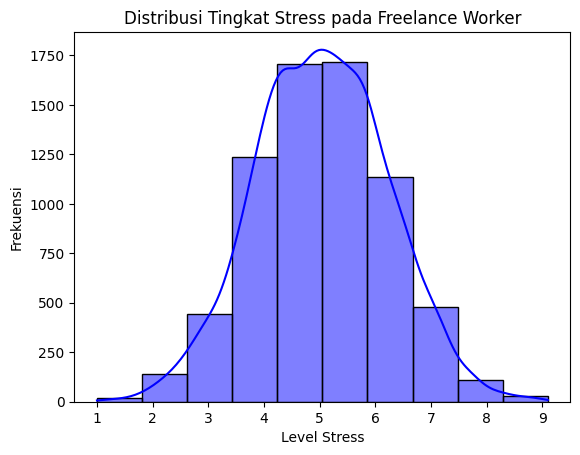

In [13]:
sns.histplot(data_stress, kde=True, color='blue', bins=10)

plt.title("Distribusi Tingkat Stress pada Freelance Worker")
plt.xlabel("Level Stress")
plt.ylabel("Frekuensi")

plt.show()


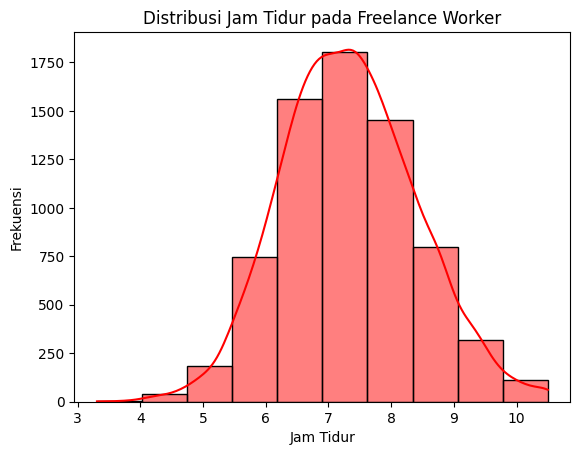

In [14]:
sns.histplot(data_sleep, kde=True, color='red', bins=10)

plt.title("Distribusi Jam Tidur pada Freelance Worker")
plt.xlabel("Jam Tidur")
plt.ylabel("Frekuensi")

plt.show()

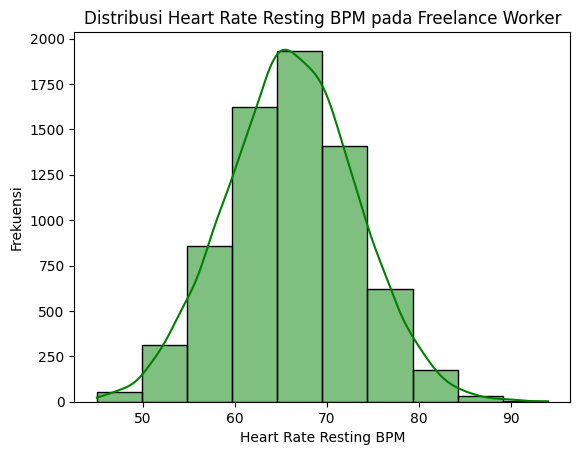

In [15]:
sns.histplot(data_heart, kde=True, color='green', bins=10)

plt.title("Distribusi Heart Rate Resting BPM pada Freelance Worker")
plt.xlabel("Heart Rate Resting BPM")
plt.ylabel("Frekuensi")

plt.show()

# Skewness dan Kurtosis 

In [16]:
kemiringan = df_freelance['stress_score'].skew()
keruncingan = df_freelance['stress_score'].kurt()

print("Bentuk Distribusi Data pada Level Stress")
print(f"Skewness (Kemiringan)   : {kemiringan:.2f}")
print(f"Kurtosis (Keruncingan) : {keruncingan:.2f}")


kemiringan = df_freelance['sleep_duration_hrs'].skew()
keruncingan = df_freelance['sleep_duration_hrs'].kurt()

print("Bentuk Distribusi Data pada Jam Tidur")
print(f"Skewness (Kemiringan)   : {kemiringan:.2f}")
print(f"Kurtosis (Keruncingan) : {keruncingan:.2f}")


kemiringan = df_freelance['heart_rate_resting_bpm'].skew()
keruncingan = df_freelance['heart_rate_resting_bpm'].kurt()

print("Bentuk Distribusi Data pada Heart Rate Resting BPM")
print(f"Skewness (Kemiringan)   : {kemiringan:.2f}")
print(f"Kurtosis (Keruncingan) : {keruncingan:.2f}")

Bentuk Distribusi Data pada Level Stress
Skewness (Kemiringan)   : 0.02
Kurtosis (Keruncingan) : -0.09
Bentuk Distribusi Data pada Jam Tidur
Skewness (Kemiringan)   : 0.16
Kurtosis (Keruncingan) : -0.02
Bentuk Distribusi Data pada Heart Rate Resting BPM
Skewness (Kemiringan)   : 0.03
Kurtosis (Keruncingan) : -0.04


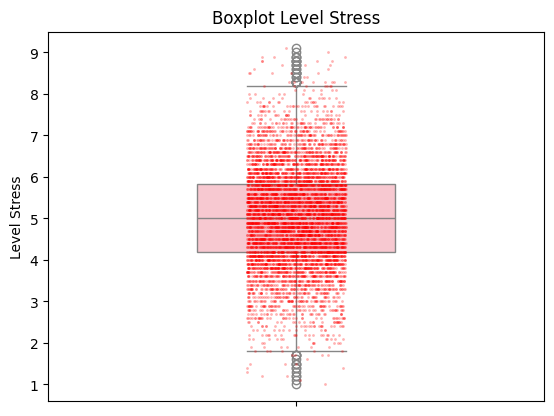

In [17]:
sns.boxplot(y=df_freelance['stress_score'], color='pink', width=0.4)

sns.stripplot(
    y=df_freelance['stress_score'],
    color='red',
    alpha=0.3,
    size=2,
    jitter=True
)

plt.title("Boxplot Level Stress")
plt.ylabel("Level Stress")

plt.show()

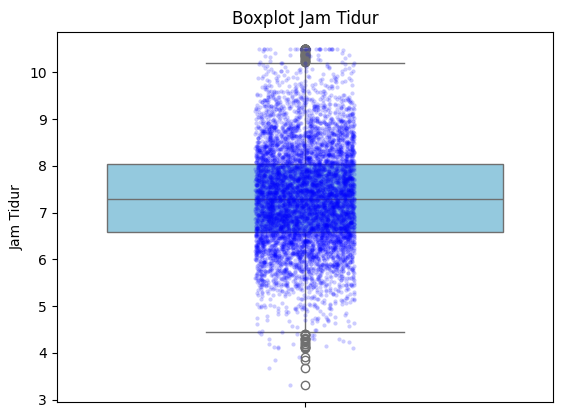

In [18]:
sns.boxplot(y=df_freelance['sleep_duration_hrs'], color='skyblue')

sns.stripplot(
    y=df_freelance['sleep_duration_hrs'],
    color='blue',
    alpha=0.2,
    size=3,
    jitter=True
)

plt.title('Boxplot Jam Tidur')
plt.ylabel('Jam Tidur')

plt.show()

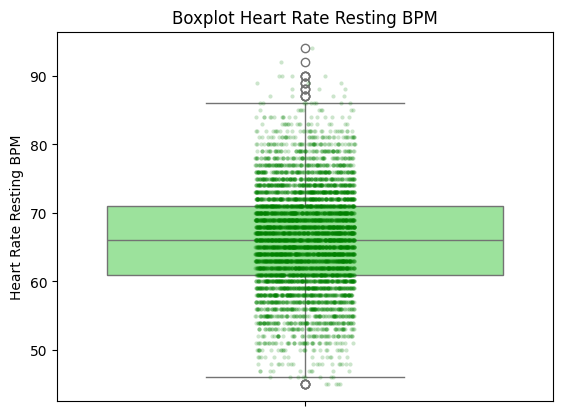

In [19]:
sns.boxplot(y=df_freelance['heart_rate_resting_bpm'], color='lightgreen')

sns.stripplot(
    y=df_freelance['heart_rate_resting_bpm'],
    color='green',
    alpha=0.2,
    size=3,
    jitter=True
)

plt.title('Boxplot Heart Rate Resting BPM')
plt.ylabel('Heart Rate Resting BPM')

plt.show()

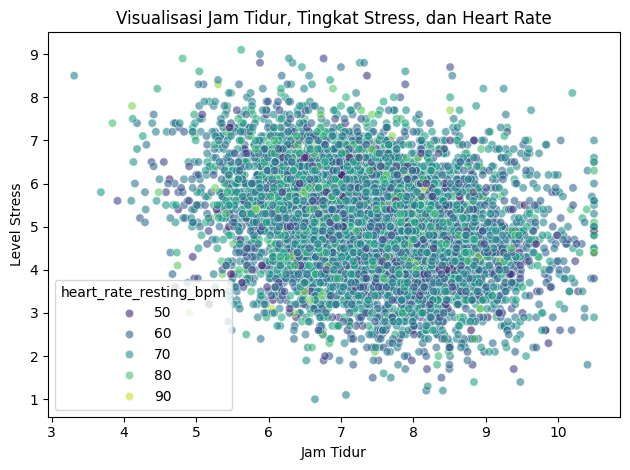

In [20]:
sns.scatterplot(
    data=df_freelance,
    x='sleep_duration_hrs',
    y='stress_score',
    hue='heart_rate_resting_bpm',
    palette='viridis',
    alpha=0.6
)

plt.title('Visualisasi Jam Tidur, Tingkat Stress, dan Heart Rate')
plt.xlabel('Jam Tidur')
plt.ylabel('Level Stress')

plt.tight_layout()
plt.show()